In [1]:
# ============================================================
# 0. Imports & Global Setup
# ============================================================
import os
import random
import itertools
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

from torchvision import transforms, datasets, models
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    ResNet, MobileNetV2, EfficientNet
)

from sklearn.model_selection import KFold
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


Device: cuda


In [2]:
# ============================================================
# 1. Transforms (with grayscale -> 3-channel conversion)
# ============================================================

def get_transforms(mode, aug="light"):
    # All images are grayscale; convert to 3 channels for pretrained models
    base_gray_to_rgb = transforms.Grayscale(num_output_channels=3)

    if aug == "light":
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            base_gray_to_rgb,
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
        ])
    elif aug == "strong":
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            base_gray_to_rgb,
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
            transforms.GaussianBlur(3),
            transforms.ToTensor(),
        ])
    else:  # "none"
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            base_gray_to_rgb,
            transforms.ToTensor(),
        ])

    test_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        base_gray_to_rgb,
        transforms.ToTensor(),
    ])

    return train_tf if mode == "train" else test_tf


In [3]:
# ============================================================
# 2. Dataloaders
# ============================================================

DATA_ROOT = "dataset"  # change if needed

def get_dataloaders(augment="light", batch_size=16):
    train_ds = datasets.ImageFolder(
        os.path.join(DATA_ROOT, "train"),
        transform=get_transforms("train", augment)
    )
    val_ds = datasets.ImageFolder(
        os.path.join(DATA_ROOT, "val"),
        transform=get_transforms("val")
    )
    test_ds = datasets.ImageFolder(
        os.path.join(DATA_ROOT, "test"),
        transform=get_transforms("val")
    )

    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_ld, val_ld, test_ld, train_ds.classes


In [4]:
# ============================================================
# 3. Model Builder (ResNet18, MobileNetV2, EfficientNet-B0)
# ============================================================

def build_model(name, num_classes=2, pretrained=True):
    name = name.lower()
    if name == "resnet18":
        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "mobilenet_v2":
        weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        model = mobilenet_v2(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name in ("efficientnet_b0", "efficientnet"):
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        model = efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {name}")

    return model.to(device)


In [6]:
# ============================================================
# 4. Training / Evaluation with TensorBoard logging
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


def run_experiment(exp_cfg, log_dir_base="runs"):
    """
    exp_cfg keys:
      - name
      - model
      - batch_size
      - lr
      - epochs
      - augment
    """
    name = exp_cfg["name"]
    print(f"\n=== Experiment: {name} ===")
    print(exp_cfg)

    # TensorBoard writer
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    log_dir = os.path.join(log_dir_base, f"{name}_{timestamp}")
    writer = SummaryWriter(log_dir=log_dir)

    train_ld, val_ld, test_ld, class_names = get_dataloaders(
        augment=exp_cfg["augment"],
        batch_size=exp_cfg["batch_size"]
    )
    model = build_model(exp_cfg["model"])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=exp_cfg["lr"])

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(exp_cfg["epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_ld, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_ld, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{exp_cfg['epochs']} | "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        # TensorBoard logging
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

    # Final test evaluation
    test_loss, test_acc = evaluate(model, test_ld, criterion)
    print(f"[{name}] Test Acc: {test_acc:.4f}")

    writer.add_hparams(
        {
            "lr": exp_cfg["lr"],
            "batch_size": exp_cfg["batch_size"],
            "model": exp_cfg["model"],
            "augment": exp_cfg["augment"],
        },
        {"hparam/test_acc": test_acc}
    )
    writer.close()

    # Plot curves
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(name)
    plt.legend()
    plt.show()

    return model, history, test_acc, class_names


In [7]:
# ============================================================
# 5. Simple Grid and Random Search Helpers
# ============================================================

def grid_search(param_space):
    """
    param_space: dict of param_name -> list of values
    returns list of dicts (all combinations)
    """
    keys = list(param_space.keys())
    combos = list(itertools.product(*param_space.values()))
    exps = []
    for i, combo in enumerate(combos):
        cfg = {k: v for k, v in zip(keys, combo)}
        cfg["name"] = f"grid_{i}_{cfg['model']}"
        exps.append(cfg)
    return exps


def random_search(param_space, n_samples=5):
    keys = list(param_space.keys())
    exps = []
    for i in range(n_samples):
        cfg = {k: random.choice(param_space[k]) for k in keys}
        cfg["name"] = f"rand_{i}_{cfg['model']}"
        exps.append(cfg)
    return exps


# Example parameter space
param_space = {
    "model": ["resnet18", "mobilenet_v2", "efficientnet_b0"],
    "batch_size": [16, 32],
    "lr": [1e-3, 5e-4],
    "epochs": [8],          # you can add [8, 12] etc.
    "augment": ["light", "strong"],
}

# Choose either grid or random:
EXPERIMENTS = random_search(param_space, n_samples=4)
# or:
# EXPERIMENTS = grid_search(param_space)

EXPERIMENTS


[{'model': 'efficientnet_b0',
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'light',
  'name': 'rand_0_efficientnet_b0'},
 {'model': 'resnet18',
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'strong',
  'name': 'rand_1_resnet18'},
 {'model': 'resnet18',
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'light',
  'name': 'rand_2_resnet18'},
 {'model': 'efficientnet_b0',
  'batch_size': 16,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'light',
  'name': 'rand_3_efficientnet_b0'}]

In [8]:
# ============================================================
# 5. Simple Grid and Random Search Helpers
# ============================================================

def grid_search(param_space):
    """
    param_space: dict of param_name -> list of values
    returns list of dicts (all combinations)
    """
    keys = list(param_space.keys())
    combos = list(itertools.product(*param_space.values()))
    exps = []
    for i, combo in enumerate(combos):
        cfg = {k: v for k, v in zip(keys, combo)}
        cfg["name"] = f"grid_{i}_{cfg['model']}"
        exps.append(cfg)
    return exps


def random_search(param_space, n_samples=5):
    keys = list(param_space.keys())
    exps = []
    for i in range(n_samples):
        cfg = {k: random.choice(param_space[k]) for k in keys}
        cfg["name"] = f"rand_{i}_{cfg['model']}"
        exps.append(cfg)
    return exps


# Example parameter space
param_space = {
    "model": ["resnet18", "mobilenet_v2", "efficientnet_b0"],
    "batch_size": [16, 32],
    "lr": [1e-3, 5e-4],
    "epochs": [8],          # you can add [8, 12] etc.
    "augment": ["light", "strong"],
}

# Choose either grid or random:
EXPERIMENTS = random_search(param_space, n_samples=4)
# or:
# EXPERIMENTS = grid_search(param_space)

EXPERIMENTS


[{'model': 'mobilenet_v2',
  'batch_size': 32,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'strong',
  'name': 'rand_0_mobilenet_v2'},
 {'model': 'mobilenet_v2',
  'batch_size': 32,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'strong',
  'name': 'rand_1_mobilenet_v2'},
 {'model': 'resnet18',
  'batch_size': 16,
  'lr': 0.0005,
  'epochs': 8,
  'augment': 'strong',
  'name': 'rand_2_resnet18'},
 {'model': 'mobilenet_v2',
  'batch_size': 32,
  'lr': 0.001,
  'epochs': 8,
  'augment': 'light',
  'name': 'rand_3_mobilenet_v2'}]


=== Experiment: rand_0_mobilenet_v2 ===
{'model': 'mobilenet_v2', 'batch_size': 32, 'lr': 0.001, 'epochs': 8, 'augment': 'strong', 'name': 'rand_0_mobilenet_v2'}


Epoch 1/8 | Train Acc: 0.9592, Val Acc: 0.6342


Epoch 2/8 | Train Acc: 0.9664, Val Acc: 0.6046


Epoch 3/8 | Train Acc: 0.9720, Val Acc: 0.6576


Epoch 4/8 | Train Acc: 0.9771, Val Acc: 0.6521


Epoch 5/8 | Train Acc: 0.9763, Val Acc: 0.6956


Epoch 6/8 | Train Acc: 0.9781, Val Acc: 0.6657


Epoch 7/8 | Train Acc: 0.9785, Val Acc: 0.6561


Epoch 8/8 | Train Acc: 0.9794, Val Acc: 0.6756
[rand_0_mobilenet_v2] Test Acc: 0.8369


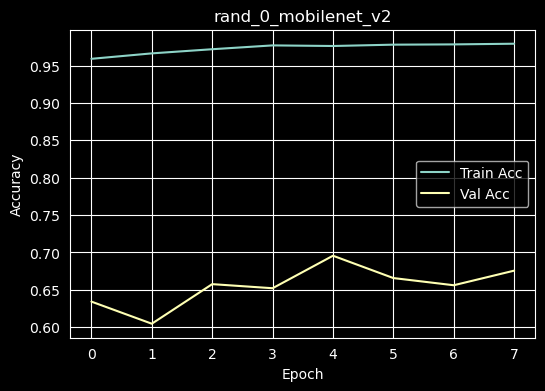


=== Experiment: rand_1_mobilenet_v2 ===
{'model': 'mobilenet_v2', 'batch_size': 32, 'lr': 0.001, 'epochs': 8, 'augment': 'strong', 'name': 'rand_1_mobilenet_v2'}


Epoch 1/8 | Train Acc: 0.9563, Val Acc: 0.6267


Epoch 2/8 | Train Acc: 0.9662, Val Acc: 0.6793


Epoch 3/8 | Train Acc: 0.9706, Val Acc: 0.6937


Epoch 4/8 | Train Acc: 0.9732, Val Acc: 0.6540


Epoch 5/8 | Train Acc: 0.9758, Val Acc: 0.6693


Epoch 6/8 | Train Acc: 0.9757, Val Acc: 0.6537


Epoch 7/8 | Train Acc: 0.9736, Val Acc: 0.5917


Epoch 8/8 | Train Acc: 0.9720, Val Acc: 0.5882
[rand_1_mobilenet_v2] Test Acc: 0.9204


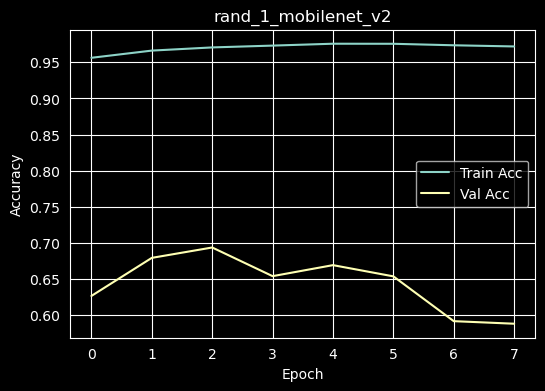


=== Experiment: rand_2_resnet18 ===
{'model': 'resnet18', 'batch_size': 16, 'lr': 0.0005, 'epochs': 8, 'augment': 'strong', 'name': 'rand_2_resnet18'}


Epoch 1/8 | Train Acc: 0.9433, Val Acc: 0.6478


Epoch 2/8 | Train Acc: 0.9601, Val Acc: 0.6107


Epoch 3/8 | Train Acc: 0.9609, Val Acc: 0.6046


Epoch 4/8 | Train Acc: 0.9664, Val Acc: 0.6187


Epoch 5/8 | Train Acc: 0.9677, Val Acc: 0.6209


Epoch 6/8 | Train Acc: 0.9680, Val Acc: 0.6931


Epoch 7/8 | Train Acc: 0.9709, Val Acc: 0.6499


Epoch 8/8 | Train Acc: 0.9732, Val Acc: 0.6302
[rand_2_resnet18] Test Acc: 0.9057


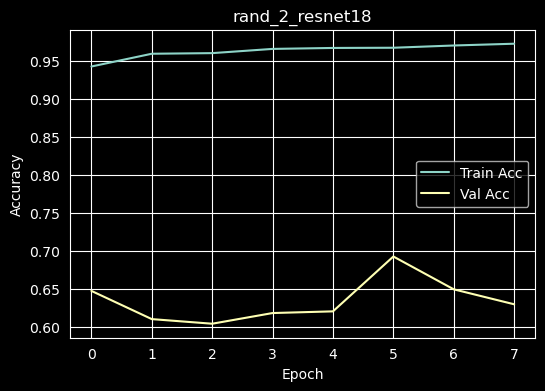


=== Experiment: rand_3_mobilenet_v2 ===
{'model': 'mobilenet_v2', 'batch_size': 32, 'lr': 0.001, 'epochs': 8, 'augment': 'light', 'name': 'rand_3_mobilenet_v2'}


Epoch 1/8 | Train Acc: 0.9576, Val Acc: 0.6181


Epoch 2/8 | Train Acc: 0.9732, Val Acc: 0.6398


Epoch 3/8 | Train Acc: 0.9772, Val Acc: 0.6181


Epoch 4/8 | Train Acc: 0.9794, Val Acc: 0.6678


Epoch 5/8 | Train Acc: 0.9784, Val Acc: 0.5719


Epoch 6/8 | Train Acc: 0.9826, Val Acc: 0.6055


Epoch 7/8 | Train Acc: 0.9702, Val Acc: 0.6577


Epoch 8/8 | Train Acc: 0.9793, Val Acc: 0.6185
[rand_3_mobilenet_v2] Test Acc: 0.9073


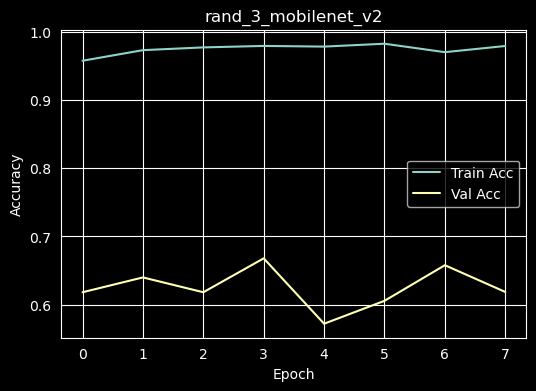

,name,model,batch_size,lr,epochs,augment,test_acc
0,rand_0_mobilenet_v2,mobilenet_v2,32,0.0010,8,strong,0.836915
1,rand_1_mobilenet_v2,mobilenet_v2,32,0.0010,8,strong,0.920380
2,rand_2_resnet18,resnet18,16,0.0005,8,strong,0.905677
3,rand_3_mobilenet_v2,mobilenet_v2,32,0.0010,8,light,0.907261


In [9]:
# ============================================================
# 6. Run Experiments and Collect Results
# ============================================================

results = []

for exp in EXPERIMENTS:
    model, history, test_acc, class_names = run_experiment(exp)
    results.append({
        "name": exp["name"],
        "model": exp["model"],
        "batch_size": exp["batch_size"],
        "lr": exp["lr"],
        "epochs": exp["epochs"],
        "augment": exp["augment"],
        "test_acc": test_acc,
    })

df_results = pd.DataFrame(results)
df_results


In [15]:
train_count = sum([len(files) for _, _, files in os.walk("dataset/train")])
val_count = sum([len(files) for _, _, files in os.walk("dataset/val")])
test_count = sum([len(files) for _, _, files in os.walk("dataset/test")])

train_count, val_count, test_count

(17681, 6758, 4421)

In [16]:
from collections import Counter

for split in ["train","val","test"]:
    ds = datasets.ImageFolder(f"dataset/{split}")
    print(split, Counter([c for _,c in ds.samples]))

train Counter({0: 8846, 1: 8835})
val Counter({0: 3958, 1: 2800})
test Counter({0: 2212, 1: 2209})


In [17]:
# ============================================================
# 7. K-Fold Cross-Validation on train/ folder
# ============================================================

def kfold_cross_val(
    model_name="resnet18",
    k=5,
    batch_size=16,
    lr=1e-3,
    epochs=5,
    augment="light"
):
    """
    Performs K-fold CV on dataset/train.
    """
    print(f"\n=== {k}-Fold CV with {model_name} ===")

    full_train_tf = get_transforms("train", augment)
    full_val_tf = get_transforms("val")

    full_train_ds_train_tf = datasets.ImageFolder(
        os.path.join(DATA_ROOT, "train"), transform=full_train_tf
    )
    full_train_ds_val_tf = datasets.ImageFolder(
        os.path.join(DATA_ROOT, "train"), transform=full_val_tf
    )

    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    indices = np.arange(len(full_train_ds_train_tf))

    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices), 1):
        print(f"\n--- Fold {fold}/{k} ---")

        train_subset = Subset(full_train_ds_train_tf, train_idx)
        val_subset = Subset(full_train_ds_val_tf, val_idx)

        train_ld = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_ld = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = build_model(model_name)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(epochs):
            train_loss, train_acc = train_one_epoch(model, train_ld, criterion, optimizer)
            val_loss, val_acc = evaluate(model, val_ld, criterion)
            print(f"Fold {fold}, Epoch {epoch+1}/{epochs} | "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        fold_accuracies.append(val_acc)

    print(f"\nK-Fold mean val accuracy: {np.mean(fold_accuracies):.4f} "
          f"+/- {np.std(fold_accuracies):.4f}")
    return fold_accuracies


# Example usage:
# kfold_accuracies = kfold_cross_val(model_name="efficientnet_b0", k=5, epochs=4)


In [18]:
kfold_accuracies = kfold_cross_val(model_name="resnet18", k=5, epochs=4)
print(kfold_accuracies)



=== 5-Fold CV with resnet18 ===

--- Fold 1/5 ---


Fold 1, Epoch 1/4 | Train Acc: 0.8668, Val Acc: 0.9228


Fold 1, Epoch 2/4 | Train Acc: 0.9195, Val Acc: 0.9415


Fold 1, Epoch 3/4 | Train Acc: 0.9301, Val Acc: 0.9203


Fold 1, Epoch 4/4 | Train Acc: 0.9288, Val Acc: 0.9435

--- Fold 2/5 ---


...

Fold 4, Epoch 4/4 | Train Acc: 0.9369, Val Acc: 0.9531

--- Fold 5/5 ---


Fold 5, Epoch 1/4 | Train Acc: 0.8841, Val Acc: 0.9222


Fold 5, Epoch 2/4 | Train Acc: 0.9214, Val Acc: 0.9457


Fold 5, Epoch 3/4 | Train Acc: 0.9357, Val Acc: 0.9409


Fold 5, Epoch 4/4 | Train Acc: 0.9355, Val Acc: 0.9010

K-Fold mean val accuracy: 0.9292 +/- 0.0280
[0.9434549052869664, 0.8902714932126696, 0.9581447963800905, 0.9530542986425339, 0.9010180995475113]


In [19]:
# ============================================================
# 8. Grad-CAM Visual Explanations
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

    def generate(self, input_tensor, target_class=None):
        """
        input_tensor: shape (1, C, H, W)
        """
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(1)

        loss = output[0, target_class]
        loss.backward()

        grads = self.gradients        # (B, C, H', W')
        acts = self.activations       # (B, C, H', W')
        weights = grads.mean(dim=(2, 3), keepdim=True)  # (B, C, 1, 1)

        cam = (weights * acts).sum(dim=1, keepdim=True)  # (B, 1, H', W')
        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = torch.nn.functional.interpolate(
            cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False
        )

        return cam  # (1,1,H,W)


def get_target_layer_for_gradcam(model):
    if isinstance(model, ResNet):
        return model.layer4[-1]
    elif isinstance(model, MobileNetV2):
        return model.features[-1]
    elif isinstance(model, EfficientNet):
        return model.features[-1]
    else:
        raise ValueError("GradCAM target layer not defined for this model type.")


def show_gradcam_examples(model, test_loader, class_names, num_images=4):
    target_layer = get_target_layer_for_gradcam(model)
    gradcam = GradCAM(model, target_layer)

    shown = 0
    for imgs, labels in test_loader:
        for i in range(imgs.size(0)):
            if shown >= num_images:
                gradcam.remove_hooks()
                return

            img = imgs[i:i+1].to(device)   # shape (1,C,H,W)
            label = labels[i].item()

            cam = gradcam.generate(img)[0, 0].cpu().numpy()  # (H,W)
            img_np = img[0].cpu().permute(1,2,0).numpy()     # (H,W,3)

            # Normalize image for plotting
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

            plt.figure(figsize=(8,3))
            plt.subplot(1,3,1)
            plt.imshow(img_np, cmap="gray")
            plt.title(f"Input ({class_names[label]})")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(cam, cmap="jet")
            plt.title("GradCAM heatmap")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(img_np, cmap="gray")
            plt.imshow(cam, cmap="jet", alpha=0.4)
            plt.title("Overlay")
            plt.axis("off")

            plt.show()

            shown += 1

    gradcam.remove_hooks()



=== Experiment: resnet18_strong_aug ===
{'name': 'resnet18_strong_aug', 'model': 'resnet18', 'batch_size': 16, 'lr': 0.001, 'epochs': 8, 'augment': 'strong'}


Epoch 1/8 | Train Acc: 0.8820, Val Acc: 0.5805


Epoch 2/8 | Train Acc: 0.9153, Val Acc: 0.6546


Epoch 3/8 | Train Acc: 0.9322, Val Acc: 0.6679


Epoch 4/8 | Train Acc: 0.9363, Val Acc: 0.6258


Epoch 5/8 | Train Acc: 0.9427, Val Acc: 0.5339


Epoch 6/8 | Train Acc: 0.9467, Val Acc: 0.6653


Epoch 7/8 | Train Acc: 0.9468, Val Acc: 0.6199


Epoch 8/8 | Train Acc: 0.9535, Val Acc: 0.5721
[resnet18_strong_aug] Test Acc: 0.9597


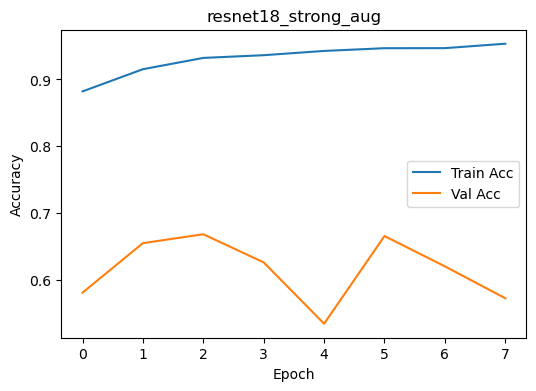

/home/abdenour/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


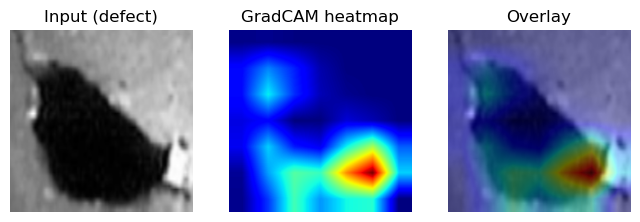

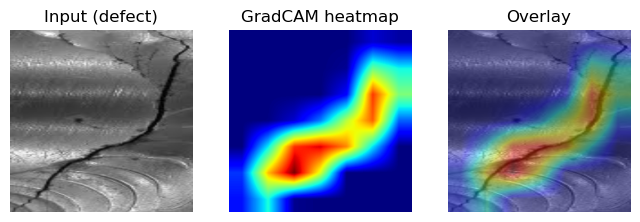

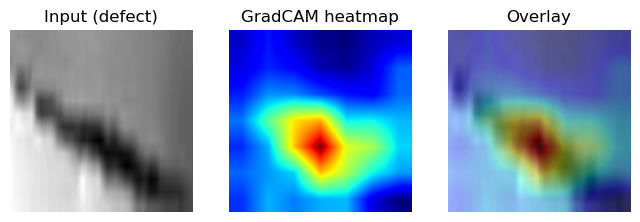

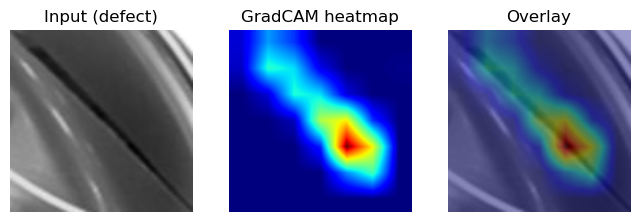

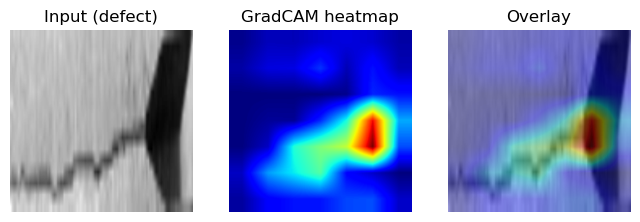

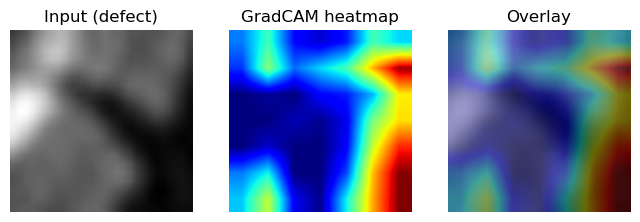

In [20]:
# ============================================================
# 9. Example: run one experiment and visualize Grad-CAM
# ============================================================

example_exp = {
    "name": "resnet18_strong_aug",
    "model": "resnet18",
    "batch_size": 16,
    "lr": 1e-3,
    "epochs": 8,
    "augment": "strong",
}

trained_model, history, test_acc, class_names = run_experiment(example_exp)

# Get fresh test loader (same batch_size doesn't matter much here)
_, _, test_loader, _ = get_dataloaders(augment="none", batch_size=8)

show_gradcam_examples(trained_model, test_loader, class_names, num_images=6)
